In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
import pandas as pd

# Load training and test datasets
train_data = pd.read_csv(
    "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv"
)

test_data = pd.read_csv(
    "/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv"
)

print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Training data shape: (60000, 785)
Test data shape: (10000, 785)


In [3]:
# Separate labels from pixel values

y = train_data["label"].values
X = train_data.drop("label", axis=1).values

print("Images shape:", X.shape)
print("Labels shape:", y.shape)


Images shape: (60000, 784)
Labels shape: (60000,)


In [4]:
# Normalize pixel values from 0-255 to 0-1

X = X / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
from sklearn.model_selection import train_test_split

# Split training data into 80% training and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 48000
Validation samples: 12000


In [6]:
# Check class distribution in training and validation sets

print("Training class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

Training class distribution:
0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Validation class distribution:
0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


In [7]:
# Check that each image is represented as a 784-dimensional vector

print("Image dimensions before flattening: 28 x 28")
print("Number of features after flattening:", X_train.shape[1])
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)

Image dimensions before flattening: 28 x 28
Number of features after flattening: 784
Training data shape: (48000, 784)
Validation data shape: (12000, 784)


In [8]:
# Use only 5000 samples for this NumPy implementation

np.random.seed(42)

X_subset = X_train[:5000]
y_subset = y_train[:5000]

print("X_subset shape:", X_subset.shape)
print("y_subset shape:", y_subset.shape)

X_subset shape: (5000, 784)
y_subset shape: (5000,)


In [9]:
# One-hot encode the labels

num_classes = 10

Y_subset = np.eye(num_classes)[y_subset]

print("One-hot encoded shape:", Y_subset.shape)
print("First label:", y_subset[0])
print("One-hot version:", Y_subset[0])

One-hot encoded shape: (5000, 10)
First label: 6
One-hot version: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [10]:
# Initialize weights and biases

np.random.seed(42)

W1 = np.random.randn(784, 64) * 0.01
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1, 10))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (784, 64)
b1 shape: (1, 64)
W2 shape: (64, 10)
b2 shape: (1, 10)


In [11]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# Forward pass
Z1 = X_subset @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
A2 = softmax(Z2)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (5000, 64)
A1 shape: (5000, 64)
Z2 shape: (5000, 10)
A2 shape: (5000, 10)


In [12]:
# Categorical Cross-Entropy Loss

epsilon = 1e-12

loss = -np.mean(
    np.sum(Y_subset * np.log(A2 + epsilon), axis=1)
)

print("Loss:", loss)

Loss: 2.3044469596800123


In [13]:
# Number of training examples
m = X_subset.shape[0]

# Gradient at output layer
dZ2 = (A2 - Y_subset) / m

# Gradients for W2 and b2
dW2 = A1.T @ dZ2
db2 = np.sum(dZ2, axis=0, keepdims=True)

print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)

dW2 shape: (64, 10)
db2 shape: (1, 10)


In [14]:
dA1 = dZ2 @ W2.T

print("dA1 shape:", dA1.shape)

dZ1 = dA1 * (Z1 > 0)

print("dZ1 shape:", dZ1.shape)

dW1 = X_subset.T @ dZ1
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)

dA1 shape: (5000, 64)
dZ1 shape: (5000, 64)
dW1 shape: (784, 64)
db1 shape: (1, 64)


In [15]:
learning_rate = 0.1

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

print("Weights and biases updated successfully!")

Weights and biases updated successfully!


In [16]:
np.random.seed(42)

W1 = np.random.randn(784, 64) * 0.01
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1, 10))

print("Weights reset successfully!")

Weights reset successfully!


In [17]:
learning_rate = 0.1
epochs = 20

loss_history = []

for epoch in range(epochs):

    # -------- Forward Pass --------
    Z1 = X_subset @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    # -------- Loss --------
    epsilon = 1e-12

    loss = -np.mean(
        np.sum(Y_subset * np.log(A2 + epsilon), axis=1)
    )

    loss_history.append(loss)

    # -------- Backward Pass --------
    m = X_subset.shape[0]

    dZ2 = (A2 - Y_subset) / m

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * (Z1 > 0)

    dW1 = X_subset.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # -------- Weight Update --------
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    print(f"Epoch {epoch + 1}/20, Loss: {loss:.4f}")

Epoch 1/20, Loss: 2.3044
Epoch 2/20, Loss: 2.3028
Epoch 3/20, Loss: 2.3012
Epoch 4/20, Loss: 2.2997
Epoch 5/20, Loss: 2.2981
Epoch 6/20, Loss: 2.2963
Epoch 7/20, Loss: 2.2943
Epoch 8/20, Loss: 2.2920
Epoch 9/20, Loss: 2.2894
Epoch 10/20, Loss: 2.2864
Epoch 11/20, Loss: 2.2828
Epoch 12/20, Loss: 2.2787
Epoch 13/20, Loss: 2.2740
Epoch 14/20, Loss: 2.2685
Epoch 15/20, Loss: 2.2622
Epoch 16/20, Loss: 2.2550
Epoch 17/20, Loss: 2.2467
Epoch 18/20, Loss: 2.2374
Epoch 19/20, Loss: 2.2268
Epoch 20/20, Loss: 2.2150


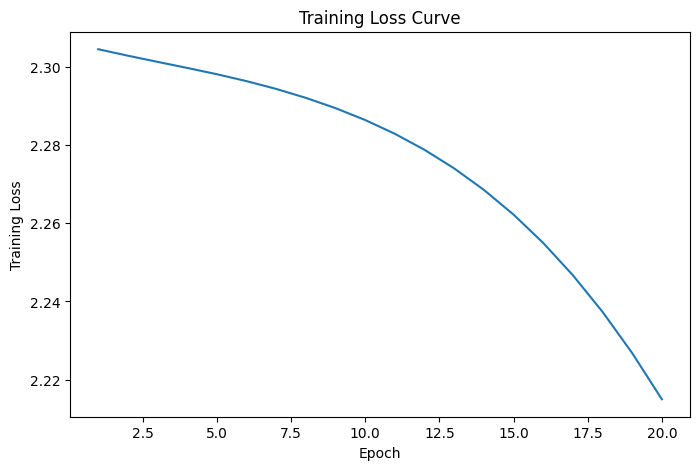

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")

plt.show()

In [19]:
np.random.seed(42)

W1_init = np.random.randn(784, 64) * 0.01
b1_init = np.zeros((1, 64))

W2_init = np.random.randn(64, 10) * 0.01
b2_init = np.zeros((1, 10))

print("Initial weights saved!")

Initial weights saved!


In [20]:
import torch
import torch.nn as nn

# Use double precision for accurate gradient comparison
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = SimpleMLP().double()

print(model)

SimpleMLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [21]:
with torch.no_grad():

    model.fc1.weight.copy_(
        torch.tensor(W1_init.T, dtype=torch.float64)
    )

    model.fc1.bias.copy_(
        torch.tensor(b1_init.flatten(), dtype=torch.float64)
    )

    model.fc2.weight.copy_(
        torch.tensor(W2_init.T, dtype=torch.float64)
    )

    model.fc2.bias.copy_(
        torch.tensor(b2_init.flatten(), dtype=torch.float64)
    )

print("Same initial weights copied to PyTorch!")

Same initial weights copied to PyTorch!


In [22]:
X_batch = X_subset[:64]
Y_batch = Y_subset[:64]
y_batch = y_subset[:64]

print("X_batch shape:", X_batch.shape)
print("Y_batch shape:", Y_batch.shape)

X_batch shape: (64, 784)
Y_batch shape: (64, 10)


In [23]:
# Use the same initial weights
W1_test = W1_init.copy()
b1_test = b1_init.copy()

W2_test = W2_init.copy()
b2_test = b2_init.copy()

# Forward pass
Z1_test = X_batch @ W1_test + b1_test
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2_test + b2_test
A2_test = softmax(Z2_test)

# Backward pass
m = X_batch.shape[0]

dZ2_test = (A2_test - Y_batch) / m

dW2_numpy = A1_test.T @ dZ2_test
db2_numpy = np.sum(dZ2_test, axis=0, keepdims=True)

dA1_test = dZ2_test @ W2_test.T

dZ1_test = dA1_test * (Z1_test > 0)

dW1_numpy = X_batch.T @ dZ1_test
db1_numpy = np.sum(dZ1_test, axis=0, keepdims=True)

print("NumPy dW1 shape:", dW1_numpy.shape)
print("NumPy dW2 shape:", dW2_numpy.shape)

NumPy dW1 shape: (784, 64)
NumPy dW2 shape: (64, 10)


In [24]:
# Convert the same batch to PyTorch tensors
X_torch = torch.tensor(X_batch, dtype=torch.float64)
Y_torch = torch.tensor(Y_batch, dtype=torch.float64)

# Clear any old gradients
model.zero_grad()

# Forward pass
logits = model(X_torch)

# Categorical cross-entropy loss
log_probs = torch.log_softmax(logits, dim=1)

loss_torch = -(Y_torch * log_probs).sum(dim=1).mean()

# Backward pass
loss_torch.backward()

print("PyTorch loss:", loss_torch.item())
print("PyTorch forward and backward completed!")

PyTorch loss: 2.3044480622431474
PyTorch forward and backward completed!


In [25]:
# Get PyTorch gradients
torch_dW1 = model.fc1.weight.grad.detach().numpy().T
torch_dW2 = model.fc2.weight.grad.detach().numpy().T

# Calculate maximum absolute difference
diff_W1 = np.max(np.abs(dW1_numpy - torch_dW1))
diff_W2 = np.max(np.abs(dW2_numpy - torch_dW2))

# Overall maximum difference
overall_diff = max(diff_W1, diff_W2)

print("Maximum absolute difference for W1:", diff_W1)
print("Maximum absolute difference for W2:", diff_W2)
print("Overall maximum difference:", overall_diff)

Maximum absolute difference for W1: 1.3010426069826053e-18
Maximum absolute difference for W2: 1.0408340855860843e-17
Overall maximum difference: 1.0408340855860843e-17


In [26]:
import torch
import torch.nn as nn

class ActivationMLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x

In [27]:
def train_model(activation, epochs=10):

    model = ActivationMLP(activation)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    train_losses = []
    val_losses = []

    # Gradient values we need
    first_epoch_gradient = None
    final_epoch_gradient = None

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        train_output = model(X_train_tensor)

        train_loss = criterion(train_output, y_train_tensor)

        train_loss.backward()

        # Mean absolute gradient of first hidden layer
        current_gradient = model.fc1.weight.grad.abs().mean().item()

        # Save gradient at epoch 1
        if epoch == 0:
            first_epoch_gradient = current_gradient

        # Save gradient at final epoch
        if epoch == epochs - 1:
            final_epoch_gradient = current_gradient

        optimizer.step()

        # Validation
        model.eval()

        with torch.no_grad():
            val_output = model(X_val_tensor)
            val_loss = criterion(val_output, y_val_tensor)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f}"
        )

    return (
        model,
        train_losses,
        val_losses,
        first_epoch_gradient,
        final_epoch_gradient
    )

In [28]:
sigmoid_model, sigmoid_train_loss, sigmoid_val_loss, sigmoid_grad_epoch1, sigmoid_grad_final = train_model(
    nn.Sigmoid(),
    epochs=10
)

Epoch 1/10 | Train Loss: 2.3697 | Val Loss: 2.3449
Epoch 2/10 | Train Loss: 2.3449 | Val Loss: 2.3241
Epoch 3/10 | Train Loss: 2.3242 | Val Loss: 2.3070
Epoch 4/10 | Train Loss: 2.3072 | Val Loss: 2.2930
Epoch 5/10 | Train Loss: 2.2933 | Val Loss: 2.2817
Epoch 6/10 | Train Loss: 2.2820 | Val Loss: 2.2723
Epoch 7/10 | Train Loss: 2.2727 | Val Loss: 2.2645
Epoch 8/10 | Train Loss: 2.2649 | Val Loss: 2.2575
Epoch 9/10 | Train Loss: 2.2579 | Val Loss: 2.2508
Epoch 10/10 | Train Loss: 2.2513 | Val Loss: 2.2439


In [29]:
tanh_model, tanh_train_loss, tanh_val_loss, tanh_grad_epoch1, tanh_grad_final = train_model(
    nn.Tanh(),
    epochs=10
)

Epoch 1/10 | Train Loss: 2.3328 | Val Loss: 2.2110
Epoch 2/10 | Train Loss: 2.2116 | Val Loss: 2.1193
Epoch 3/10 | Train Loss: 2.1204 | Val Loss: 2.0348
Epoch 4/10 | Train Loss: 2.0363 | Val Loss: 1.9505
Epoch 5/10 | Train Loss: 1.9523 | Val Loss: 1.8668
Epoch 6/10 | Train Loss: 1.8689 | Val Loss: 1.7865
Epoch 7/10 | Train Loss: 1.7889 | Val Loss: 1.7123
Epoch 8/10 | Train Loss: 1.7149 | Val Loss: 1.6453
Epoch 9/10 | Train Loss: 1.6481 | Val Loss: 1.5852
Epoch 10/10 | Train Loss: 1.5881 | Val Loss: 1.5309


In [30]:
relu_model, relu_train_loss, relu_val_loss, relu_first_gradient, relu_final_gradient = train_model(
    nn.ReLU(),
    epochs=10
)

Epoch 1/10 | Train Loss: 2.3093 | Val Loss: 2.2686
Epoch 2/10 | Train Loss: 2.2686 | Val Loss: 2.2313
Epoch 3/10 | Train Loss: 2.2314 | Val Loss: 2.1896
Epoch 4/10 | Train Loss: 2.1900 | Val Loss: 2.1389
Epoch 5/10 | Train Loss: 2.1396 | Val Loss: 2.0814
Epoch 6/10 | Train Loss: 2.0824 | Val Loss: 2.0184
Epoch 7/10 | Train Loss: 2.0198 | Val Loss: 1.9507
Epoch 8/10 | Train Loss: 1.9525 | Val Loss: 1.8784
Epoch 9/10 | Train Loss: 1.8807 | Val Loss: 1.8030
Epoch 10/10 | Train Loss: 1.8056 | Val Loss: 1.7255


In [31]:
leaky_relu_model, leaky_relu_train_loss, leaky_relu_val_loss, leaky_relu_first_gradient, leaky_relu_final_gradient = train_model(
    nn.LeakyReLU(negative_slope=0.01),
    epochs=10
)

Epoch 1/10 | Train Loss: 2.3082 | Val Loss: 2.2621
Epoch 2/10 | Train Loss: 2.2621 | Val Loss: 2.2162
Epoch 3/10 | Train Loss: 2.2163 | Val Loss: 2.1638
Epoch 4/10 | Train Loss: 2.1643 | Val Loss: 2.1055
Epoch 5/10 | Train Loss: 2.1063 | Val Loss: 2.0399
Epoch 6/10 | Train Loss: 2.0412 | Val Loss: 1.9704
Epoch 7/10 | Train Loss: 1.9721 | Val Loss: 1.8990
Epoch 8/10 | Train Loss: 1.9012 | Val Loss: 1.8250
Epoch 9/10 | Train Loss: 1.8276 | Val Loss: 1.7508
Epoch 10/10 | Train Loss: 1.7539 | Val Loss: 1.6775


In [122]:
# Part 2 - Test Accuracy for All Activation Functions

# Convert test data to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


def get_test_accuracy(model):
    model.eval()

    with torch.no_grad():
        output = model(X_test_tensor)
        predictions = torch.argmax(output, dim=1)

        accuracy = (
            (predictions == y_test_tensor).float().mean().item() * 100
        )

    return accuracy


# Calculate test accuracy
sigmoid_test_accuracy = get_test_accuracy(sigmoid_model)
tanh_test_accuracy = get_test_accuracy(tanh_model)
relu_test_accuracy = get_test_accuracy(relu_model)
leaky_relu_test_accuracy = get_test_accuracy(leaky_relu_model)


# Display results
print(" TESTING ACCURACY")
print("-----------------------")
print(f"Sigmoid Test Accuracy:     {sigmoid_test_accuracy:.2f}%")
print(f"Tanh Test Accuracy:        {tanh_test_accuracy:.2f}%")
print(f"ReLU Test Accuracy:        {relu_test_accuracy:.2f}%")
print(f"Leaky ReLU Test Accuracy:  {leaky_relu_test_accuracy:.2f}%")

 TESTING ACCURACY
-----------------------
Sigmoid Test Accuracy:     26.75%
Tanh Test Accuracy:        60.40%
ReLU Test Accuracy:        52.80%
Leaky ReLU Test Accuracy:  50.24%


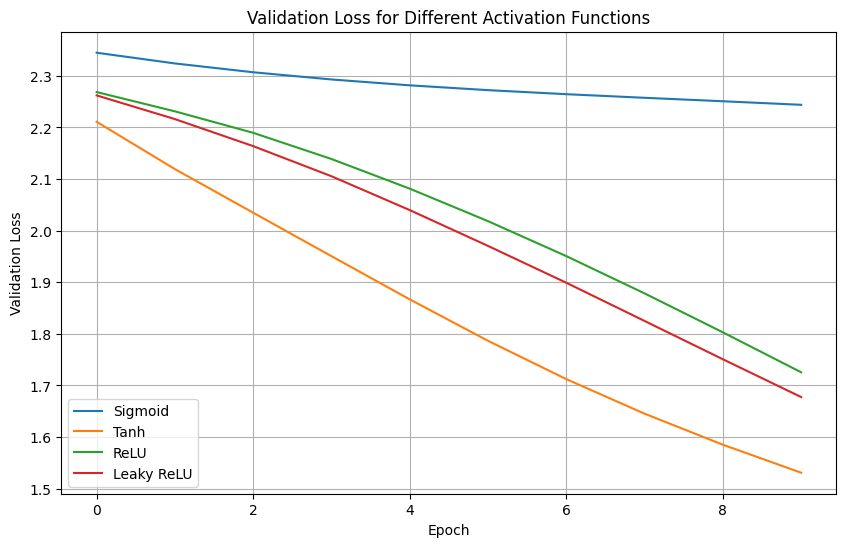

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(sigmoid_val_loss, label="Sigmoid")
plt.plot(tanh_val_loss, label="Tanh")
plt.plot(relu_val_loss, label="ReLU")
plt.plot(leaky_relu_val_loss, label="Leaky ReLU")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
relu_model, relu_train_loss, relu_val_loss, relu_grad_epoch1, relu_grad_final = train_model(
    nn.ReLU(),
    epochs=10
)

Epoch 1/10 | Train Loss: 2.3086 | Val Loss: 2.2629
Epoch 2/10 | Train Loss: 2.2634 | Val Loss: 2.2215
Epoch 3/10 | Train Loss: 2.2224 | Val Loss: 2.1742
Epoch 4/10 | Train Loss: 2.1754 | Val Loss: 2.1226
Epoch 5/10 | Train Loss: 2.1241 | Val Loss: 2.0663
Epoch 6/10 | Train Loss: 2.0681 | Val Loss: 2.0051
Epoch 7/10 | Train Loss: 2.0073 | Val Loss: 1.9396
Epoch 8/10 | Train Loss: 1.9421 | Val Loss: 1.8697
Epoch 9/10 | Train Loss: 1.8725 | Val Loss: 1.7965
Epoch 10/10 | Train Loss: 1.7996 | Val Loss: 1.7217


In [34]:
print("Sigmoid Gradient - Epoch 1:", sigmoid_grad_epoch1)
print("Sigmoid Gradient - Final Epoch:", sigmoid_grad_final)

print("ReLU Gradient - Epoch 1:", relu_grad_epoch1)
print("ReLU Gradient - Final Epoch:", relu_grad_final)

Sigmoid Gradient - Epoch 1: 9.650833089835942e-05
Sigmoid Gradient - Final Epoch: 6.270193262025714e-05
ReLU Gradient - Epoch 1: 0.0005219990271143615
ReLU Gradient - Final Epoch: 0.0005636627320200205


In [35]:
relu_model.eval()

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

with torch.no_grad():
    hidden_output = relu_model.fc1(X_val_tensor)

# Check which neurons output zero for every validation sample
dead_units = (hidden_output == 0).all(dim=0)

dead_percentage = dead_units.float().mean().item() * 100

print("Number of dead ReLU units:", dead_units.sum().item())
print("Total hidden units:", hidden_output.shape[1])
print(f"Dead-unit percentage: {dead_percentage:.2f}%")

Number of dead ReLU units: 0
Total hidden units: 128
Dead-unit percentage: 0.00%


In [36]:
#Overall, ReLU performed better than Sigmoid because it showed larger gradients and a faster decrease in validation loss.
#Sigmoid showed smaller and decreasing gradients, indicating weaker gradient flow and a tendency
#toward vanishing gradients. The ReLU model had 0.00% dead units, so no dead-unit problem was observed in the validation batch.

In [37]:

# ============================================================
# PART 3: PREPARE TEST DATA
# ============================================================

X_test = test_data.drop("label", axis=1).values
y_test = test_data["label"].values

# Normalize pixels
X_test = X_test / 255.0

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Test images shape: (10000, 784)
Test labels shape: (10000,)


In [38]:
# ============================================================
# PART 3: CLASSIFICATION MODEL
# ============================================================

class ClassificationMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [39]:
# ============================================================
# PART 3C: CONVERT DATA TO PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("PyTorch tensors created successfully!")

PyTorch tensors created successfully!


In [40]:
# ============================================================
# PART 3: TRAIN WITH CATEGORICAL CROSS-ENTROPY
# ============================================================

torch.manual_seed(42)

ce_model = ClassificationMLP()

ce_criterion = nn.CrossEntropyLoss()

ce_optimizer = torch.optim.Adam(
    ce_model.parameters(),
    lr=0.001
)

ce_train_losses = []

epochs = 10

for epoch in range(epochs):

    ce_model.train()

    ce_optimizer.zero_grad()

    output = ce_model(X_train_tensor)

    loss = ce_criterion(
        output,
        y_train_tensor
    )

    loss.backward()

    ce_optimizer.step()

    ce_train_losses.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {loss.item():.4f}"
    )

Epoch 1/10, Loss: 2.3092
Epoch 2/10, Loss: 2.2618
Epoch 3/10, Loss: 2.2150
Epoch 4/10, Loss: 2.1629
Epoch 5/10, Loss: 2.1040
Epoch 6/10, Loss: 2.0388
Epoch 7/10, Loss: 1.9687
Epoch 8/10, Loss: 1.8938
Epoch 9/10, Loss: 1.8150
Epoch 10/10, Loss: 1.7343


In [41]:
# ============================================================
# PART 3E: CROSS-ENTROPY TEST ACCURACY
# ============================================================

ce_model.eval()

with torch.no_grad():

    test_output = ce_model(
        X_test_tensor
    )

    predictions = torch.argmax(
        test_output,
        dim=1
    )

    ce_correct = (
        predictions == y_test_tensor
    ).sum().item()

    ce_test_accuracy = (
        ce_correct / len(y_test_tensor)
    ) * 100


print(
    "Cross-Entropy Test Accuracy:",
    ce_test_accuracy,
    "%"
)

Cross-Entropy Test Accuracy: 51.559999999999995 %


In [42]:
# ============================================================
# PART 3F: ONE-HOT TARGETS FOR MSE
# ============================================================

y_train_onehot = torch.zeros(
    len(y_train_tensor),
    10
)

y_train_onehot[
    torch.arange(len(y_train_tensor)),
    y_train_tensor
] = 1.0

print(
    "One-hot training targets:",
    y_train_onehot.shape
)

One-hot training targets: torch.Size([48000, 10])


In [43]:
# ============================================================
# PART 3G: TRAIN WITH MEAN SQUARED ERROR
# ============================================================

torch.manual_seed(42)

mse_model = ClassificationMLP()

mse_criterion = nn.MSELoss()

mse_optimizer = torch.optim.Adam(
    mse_model.parameters(),
    lr=0.001
)

mse_train_losses = []

for epoch in range(epochs):

    mse_model.train()

    mse_optimizer.zero_grad()

    logits = mse_model(
        X_train_tensor
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )

    loss = mse_criterion(
        probabilities,
        y_train_onehot
    )

    loss.backward()

    mse_optimizer.step()

    mse_train_losses.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {loss.item():.4f}"
    )

Epoch 1/10, Loss: 0.0901
Epoch 2/10, Loss: 0.0892
Epoch 3/10, Loss: 0.0882
Epoch 4/10, Loss: 0.0870
Epoch 5/10, Loss: 0.0857
Epoch 6/10, Loss: 0.0840
Epoch 7/10, Loss: 0.0821
Epoch 8/10, Loss: 0.0799
Epoch 9/10, Loss: 0.0774
Epoch 10/10, Loss: 0.0749


In [44]:
# ============================================================
# PART 3H: MSE TEST ACCURACY
# ============================================================

mse_model.eval()

with torch.no_grad():

    test_logits = mse_model(
        X_test_tensor
    )

    test_probabilities = torch.softmax(
        test_logits,
        dim=1
    )

    predictions = torch.argmax(
        test_probabilities,
        dim=1
    )

    mse_correct = (
        predictions == y_test_tensor
    ).sum().item()

    mse_test_accuracy = (
        mse_correct / len(y_test_tensor)
    ) * 100


print(
    "MSE Test Accuracy:",
    mse_test_accuracy,
    "%"
)

MSE Test Accuracy: 46.800000000000004 %


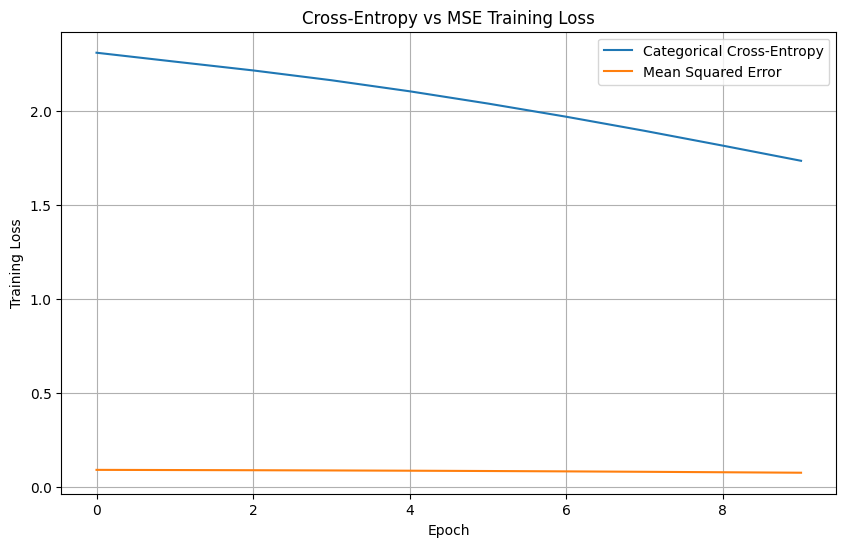

In [45]:
# ============================================================
# PART 3I: COMPARE TRAINING CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    ce_train_losses,
    label="Categorical Cross-Entropy"
)

plt.plot(
    mse_train_losses,
    label="Mean Squared Error"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Cross-Entropy vs MSE Training Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [46]:
# ============================================================
# PART 3J: CLASSIFICATION LOSS COMPARISON
# ============================================================

print("Classification Results")
print("=" * 40)

print(
    "Cross-Entropy Test Accuracy:",
    ce_test_accuracy,
    "%"
)

print(
    "MSE Test Accuracy:",
    mse_test_accuracy,
    "%"
)

Classification Results
Cross-Entropy Test Accuracy: 51.559999999999995 %
MSE Test Accuracy: 46.800000000000004 %


In [47]:
# ============================================================
# PART 3K: LOAD TABULAR REGRESSION DATASET
# ============================================================

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

diabetes = load_diabetes()

X_reg = diabetes.data
y_reg = diabetes.target

print("Regression features:", X_reg.shape)
print("Regression targets:", y_reg.shape)

Regression features: (442, 10)
Regression targets: (442,)


In [48]:
# ============================================================
# PART 3L: REGRESSION TRAIN/TEST SPLIT
# ============================================================

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_reg_train = scaler.fit_transform(
    X_reg_train
)

X_reg_test = scaler.transform(
    X_reg_test
)

print(
    "Regression training samples:",
    X_reg_train.shape[0]
)

print(
    "Regression test samples:",
    X_reg_test.shape[0]
)

Regression training samples: 353
Regression test samples: 89


In [49]:
# ============================================================
# PART 3: REGRESSION MLP
# ============================================================

class RegressionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

    def forward(self, x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [50]:
# ============================================================
# PART 3N: TRAIN REGRESSION MODEL
# ============================================================

X_reg_train_tensor = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train_tensor = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).view(-1, 1)

X_reg_test_tensor = torch.tensor(
    X_reg_test,
    dtype=torch.float32
)

y_reg_test_tensor = torch.tensor(
    y_reg_test,
    dtype=torch.float32
).view(-1, 1)


torch.manual_seed(42)

reg_model = RegressionMLP()

reg_criterion = nn.MSELoss()

reg_optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=0.01
)


for epoch in range(100):

    reg_model.train()

    reg_optimizer.zero_grad()

    output = reg_model(
        X_reg_train_tensor
    )

    loss = reg_criterion(
        output,
        y_reg_train_tensor
    )

    loss.backward()

    reg_optimizer.step()


print("Regression model training completed!")

Regression model training completed!


In [51]:
# ============================================================
# PART 3O: REGRESSION TEST METRICS
# ============================================================

reg_model.eval()

with torch.no_grad():

    reg_predictions = reg_model(
        X_reg_test_tensor
    ).numpy()


y_actual = y_reg_test

mse = mean_squared_error(
    y_actual,
    reg_predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_actual,
    reg_predictions
)


print("Regression Test Results")
print("=" * 40)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)

Regression Test Results
MSE : 3349.9801165559525
RMSE: 57.87901274690121
MAE : 46.26186139396067


In [52]:
#Cross-entropy is better suited to classification because it directly measures the difference between the predicted class probabilities and the correct class. 
#MSE is mainly designed for continuous regression values,
#so its gradients are less effective for probability-based classification and usually lead to slower convergence.

In [53]:
# ============================================================
# PART 4A: OPTIMISER TRAINING FUNCTION
# ============================================================

import time


def train_optimizer(
    optimizer_name,
    learning_rate=0.001,
    epochs=20
):

    torch.manual_seed(42)

    model = ClassificationMLP()

    criterion = nn.CrossEntropyLoss()


    # Choose optimizer
    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD + momentum":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )


    train_losses = []
    val_accuracies = []

    epoch_85 = None


    # Start timer
    start_time = time.time()


    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        optimizer.zero_grad()

        output = model(
            X_train_tensor
        )

        loss = criterion(
            output,
            y_train_tensor
        )

        loss.backward()

        optimizer.step()

        train_losses.append(
            loss.item()
        )


        # -------------------------
        # Validation accuracy
        # -------------------------

        model.eval()

        with torch.no_grad():

            val_output = model(
                X_val_tensor
            )

            predictions = torch.argmax(
                val_output,
                dim=1
            )

            accuracy = (
                (predictions == y_val_tensor)
                .float()
                .mean()
                .item()
                * 100
            )

        val_accuracies.append(
            accuracy
        )


        # First epoch reaching 85%
        if (
            epoch_85 is None
            and accuracy >= 85
        ):
            epoch_85 = epoch + 1


        print(
            f"{optimizer_name} | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {loss.item():.4f} | "
            f"Val Accuracy: {accuracy:.2f}%"
        )


    # Stop timer
    wall_time = time.time() - start_time


    final_accuracy = val_accuracies[-1]


    return (
        model,
        train_losses,
        val_accuracies,
        epoch_85,
        final_accuracy,
        wall_time
    )

In [54]:
# ============================================================
# PART 4B: SAME LEARNING RATE FOR ALL OPTIMIZERS
# ============================================================

same_lr = 0.001
optimizer_epochs = 20


sgd_result = train_optimizer(
    "SGD",
    learning_rate=same_lr,
    epochs=optimizer_epochs
)

momentum_result = train_optimizer(
    "SGD + momentum",
    learning_rate=same_lr,
    epochs=optimizer_epochs
)

rmsprop_result = train_optimizer(
    "RMSProp",
    learning_rate=same_lr,
    epochs=optimizer_epochs
)

adam_result = train_optimizer(
    "Adam",
    learning_rate=same_lr,
    epochs=optimizer_epochs
)

SGD | Epoch 1/20 | Loss: 2.3092 | Val Accuracy: 5.87%
SGD | Epoch 2/20 | Loss: 2.3091 | Val Accuracy: 5.89%
SGD | Epoch 3/20 | Loss: 2.3090 | Val Accuracy: 5.91%
SGD | Epoch 4/20 | Loss: 2.3089 | Val Accuracy: 5.91%
SGD | Epoch 5/20 | Loss: 2.3088 | Val Accuracy: 5.97%
SGD | Epoch 6/20 | Loss: 2.3087 | Val Accuracy: 6.04%
SGD | Epoch 7/20 | Loss: 2.3086 | Val Accuracy: 6.11%
SGD | Epoch 8/20 | Loss: 2.3085 | Val Accuracy: 6.17%
SGD | Epoch 9/20 | Loss: 2.3084 | Val Accuracy: 6.17%
SGD | Epoch 10/20 | Loss: 2.3083 | Val Accuracy: 6.22%
SGD | Epoch 11/20 | Loss: 2.3082 | Val Accuracy: 6.23%
SGD | Epoch 12/20 | Loss: 2.3081 | Val Accuracy: 6.28%
SGD | Epoch 13/20 | Loss: 2.3080 | Val Accuracy: 6.35%
SGD | Epoch 14/20 | Loss: 2.3079 | Val Accuracy: 6.42%
SGD | Epoch 15/20 | Loss: 2.3078 | Val Accuracy: 6.44%
SGD | Epoch 16/20 | Loss: 2.3077 | Val Accuracy: 6.50%
SGD | Epoch 17/20 | Loss: 2.3076 | Val Accuracy: 6.53%
SGD | Epoch 18/20 | Loss: 2.3075 | Val Accuracy: 6.62%
SGD | Epoch 19/20 |

In [55]:
# ============================================================
# PART 4C: TUNED LEARNING RATES
# ============================================================

sgd_tuned = train_optimizer(
    "SGD",
    learning_rate=0.01,
    epochs=optimizer_epochs
)

momentum_tuned = train_optimizer(
    "SGD + momentum",
    learning_rate=0.01,
    epochs=optimizer_epochs
)

rmsprop_tuned = train_optimizer(
    "RMSProp",
    learning_rate=0.001,
    epochs=optimizer_epochs
)

adam_tuned = train_optimizer(
    "Adam",
    learning_rate=0.001,
    epochs=optimizer_epochs
)

SGD | Epoch 1/20 | Loss: 2.3092 | Val Accuracy: 6.22%
SGD | Epoch 2/20 | Loss: 2.3082 | Val Accuracy: 6.77%
SGD | Epoch 3/20 | Loss: 2.3073 | Val Accuracy: 7.35%
SGD | Epoch 4/20 | Loss: 2.3063 | Val Accuracy: 7.87%
SGD | Epoch 5/20 | Loss: 2.3053 | Val Accuracy: 8.37%
SGD | Epoch 6/20 | Loss: 2.3044 | Val Accuracy: 8.83%
SGD | Epoch 7/20 | Loss: 2.3034 | Val Accuracy: 9.24%
SGD | Epoch 8/20 | Loss: 2.3025 | Val Accuracy: 9.63%
SGD | Epoch 9/20 | Loss: 2.3015 | Val Accuracy: 10.13%
SGD | Epoch 10/20 | Loss: 2.3006 | Val Accuracy: 10.60%
SGD | Epoch 11/20 | Loss: 2.2996 | Val Accuracy: 10.94%
SGD | Epoch 12/20 | Loss: 2.2987 | Val Accuracy: 11.28%
SGD | Epoch 13/20 | Loss: 2.2977 | Val Accuracy: 11.63%
SGD | Epoch 14/20 | Loss: 2.2968 | Val Accuracy: 11.92%
SGD | Epoch 15/20 | Loss: 2.2959 | Val Accuracy: 12.18%
SGD | Epoch 16/20 | Loss: 2.2949 | Val Accuracy: 12.38%
SGD | Epoch 17/20 | Loss: 2.2940 | Val Accuracy: 12.63%
SGD | Epoch 18/20 | Loss: 2.2931 | Val Accuracy: 12.90%
SGD | Epo

In [56]:
# ============================================================
# PART 4D: OPTIMISER COMPARISON TABLE
# ============================================================

optimizer_names = [
    "SGD",
    "SGD + momentum",
    "RMSProp",
    "Adam"
]

tuned_results = [
    sgd_tuned,
    momentum_tuned,
    rmsprop_tuned,
    adam_tuned
]

learning_rates = [
    0.01,
    0.01,
    0.001,
    0.001
]


results_table = pd.DataFrame({

    "Optimiser": optimizer_names,

    "Learning rate": learning_rates,

    "Epochs to reach 85% validation accuracy": [
        result[3]
        for result in tuned_results
    ],

    "Final validation accuracy (%)": [
        result[4]
        for result in tuned_results
    ],

    "Wall-clock time (seconds)": [
        result[5]
        for result in tuned_results
    ]
})


results_table

,Optimiser,Learning rate,Epochs to reach 85% validation accuracy,Final validation accuracy (%),Wall-clock time (seconds)
0,SGD,0.010,None,13.416667,3.089837
1,SGD + momentum,0.010,None,19.366667,3.175148
2,RMSProp,0.001,None,69.475001,3.150482
3,Adam,0.001,None,66.049999,3.156087


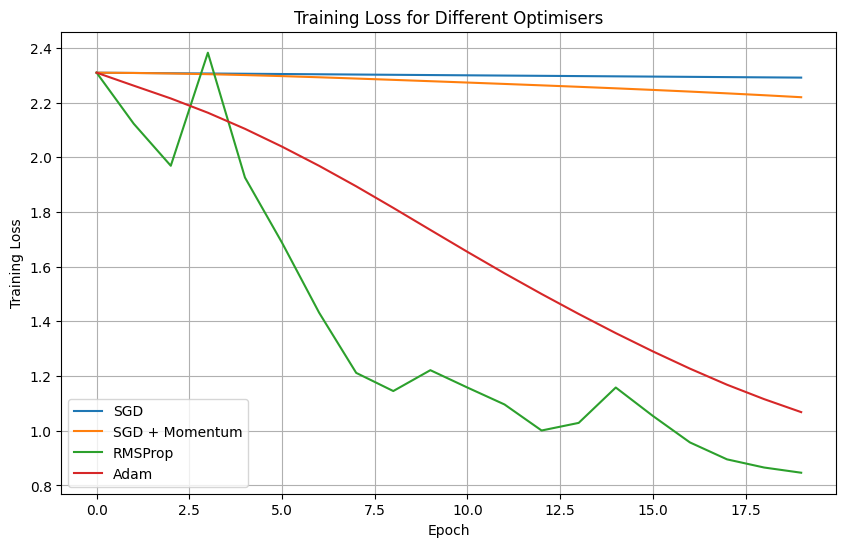

In [57]:
# ============================================================
# PART 4E: FOUR OPTIMISER TRAINING LOSS CURVES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    sgd_tuned[1],
    label="SGD"
)

plt.plot(
    momentum_tuned[1],
    label="SGD + Momentum"
)

plt.plot(
    rmsprop_tuned[1],
    label="RMSProp"
)

plt.plot(
    adam_tuned[1],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.title(
    "Training Loss for Different Optimisers"
)

plt.legend()
plt.grid(True)

plt.show()

In [58]:
# ============================================================
# PART 4F: SAME LEARNING RATE RESULTS
# ============================================================

same_lr_results = [
    sgd_result,
    momentum_result,
    rmsprop_result,
    adam_result
]

same_lr_table = pd.DataFrame({

    "Optimiser": optimizer_names,

    "Learning rate": [
        same_lr,
        same_lr,
        same_lr,
        same_lr
    ],

    "Epochs to reach 85%": [
        result[3]
        for result in same_lr_results
    ],

    "Final validation accuracy (%)": [
        result[4]
        for result in same_lr_results
    ],

    "Wall-clock time (seconds)": [
        result[5]
        for result in same_lr_results
    ]
})

same_lr_table

,Optimiser,Learning rate,Epochs to reach 85%,Final validation accuracy (%),Wall-clock time (seconds)
0,SGD,0.001,None,6.766666,3.285801
1,SGD + momentum,0.001,None,11.308333,3.223134
2,RMSProp,0.001,None,69.475001,3.289192
3,Adam,0.001,None,66.049999,3.272192


In [59]:
#RMSProp was the best-performing optimizer in this experiment.
#It achieved the highest final validation accuracy of 69.48%, compared with 66.05% for Adam, 19.37% for SGD with momentum, and 13.42% for SGD. Although none of the optimizers reached 85% validation accuracy within 20 epochs,
#RMSProp showed the strongest learning and performance.

In [60]:
# PART 6 
# Use only 2,000 training samples
X_train_2000 = X_train[:2000]
y_train_2000 = y_train[:2000]

print("Training samples:", X_train_2000.shape[0])
print("Features:", X_train_2000.shape[1])

Training samples: 2000
Features: 784


In [61]:
X_train_2000_tensor = torch.tensor(X_train_2000, dtype=torch.float32)
y_train_2000_tensor = torch.tensor(y_train_2000, dtype=torch.long)

print(X_train_2000_tensor.shape)
print(y_train_2000_tensor.shape)

torch.Size([2000, 784])
torch.Size([2000])


In [62]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc5 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)

        return x

In [63]:
torch.manual_seed(42)

overfit_model = OverfitMLP()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    overfit_model.parameters(),
    lr=0.001
)

epochs = 200

overfit_train_losses = []
overfit_val_losses = []

overfit_train_acc = []
overfit_val_acc = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    overfit_model.train()

    optimizer.zero_grad()

    train_output = overfit_model(X_train_2000_tensor)

    train_loss = criterion(
        train_output,
        y_train_2000_tensor
    )

    train_loss.backward()
    optimizer.step()

    # Training accuracy
    train_predictions = torch.argmax(
        train_output,
        dim=1
    )

    train_accuracy = (
        (train_predictions == y_train_2000_tensor)
        .float()
        .mean()
        .item() * 100
    )

    # -------------------------
    # Validation
    # -------------------------
    overfit_model.eval()

    with torch.no_grad():

        val_output = overfit_model(X_val_tensor)

        val_loss = criterion(
            val_output,
            y_val_tensor
        )

        val_predictions = torch.argmax(
            val_output,
            dim=1
        )

        val_accuracy = (
            (val_predictions == y_val_tensor)
            .float()
            .mean()
            .item() * 100
        )

    overfit_train_losses.append(train_loss.item())
    overfit_val_losses.append(val_loss.item())

    overfit_train_acc.append(train_accuracy)
    overfit_val_acc.append(val_accuracy)

    print(
        f"Epoch {epoch+1:3d}/{epochs} | "
        f"Train Loss: {train_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch   1/200 | Train Loss: 2.3027 | Train Acc: 9.30% | Val Loss: 2.2768 | Val Acc: 23.66%
Epoch   2/200 | Train Loss: 2.2761 | Train Acc: 25.25% | Val Loss: 2.2224 | Val Acc: 32.76%
Epoch   3/200 | Train Loss: 2.2207 | Train Acc: 34.90% | Val Loss: 2.1165 | Val Acc: 39.21%
Epoch   4/200 | Train Loss: 2.1131 | Train Acc: 41.70% | Val Loss: 1.9357 | Val Acc: 36.07%
Epoch   5/200 | Train Loss: 1.9299 | Train Acc: 38.50% | Val Loss: 1.7002 | Val Acc: 34.46%
Epoch   6/200 | Train Loss: 1.6901 | Train Acc: 37.15% | Val Loss: 1.4465 | Val Acc: 50.42%
Epoch   7/200 | Train Loss: 1.4397 | Train Acc: 52.05% | Val Loss: 1.2628 | Val Acc: 56.72%
Epoch   8/200 | Train Loss: 1.2716 | Train Acc: 56.55% | Val Loss: 1.2796 | Val Acc: 51.17%
Epoch   9/200 | Train Loss: 1.2710 | Train Acc: 51.30% | Val Loss: 1.2884 | Val Acc: 47.42%
Epoch  10/200 | Train Loss: 1.2745 | Train Acc: 48.55% | Val Loss: 1.0803 | Val Acc: 59.62%
Epoch  11/200 | Train Loss: 1.0888 | Train Acc: 59.15% | Val Loss: 1.1649 | Val A

In [64]:
import numpy as np

loss_difference = np.array(overfit_val_losses) - np.array(overfit_train_losses)

separation_epoch = np.argmax(loss_difference) + 1

print("Epoch with largest loss separation:", separation_epoch)

Epoch with largest loss separation: 138


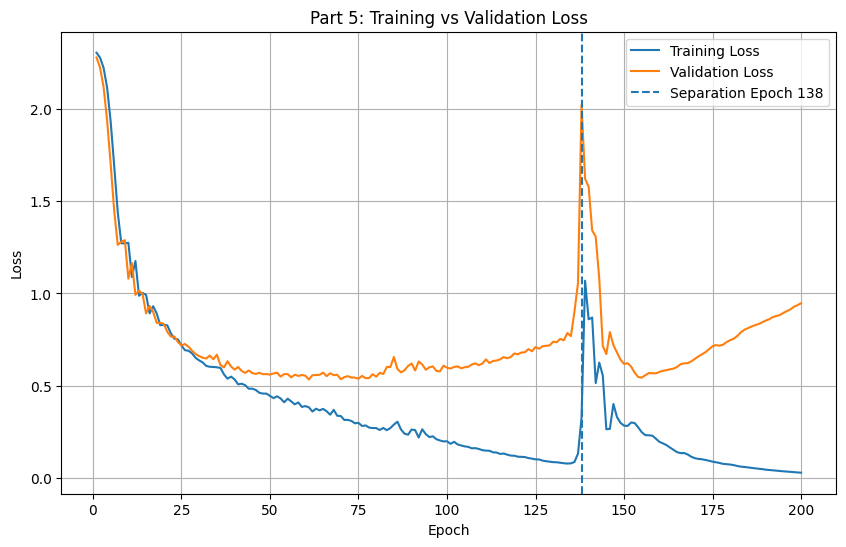

In [65]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    overfit_train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, epochs + 1),
    overfit_val_losses,
    label="Validation Loss"
)

plt.axvline(
    separation_epoch,
    linestyle="--",
    label=f"Separation Epoch {separation_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 5: Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [66]:
final_train_accuracy = overfit_train_acc[-1]
final_val_accuracy = overfit_val_acc[-1]

generalisation_gap = (
    final_train_accuracy - final_val_accuracy
)

print(f"Final Training Accuracy: {final_train_accuracy:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy:.2f}%")
print(f"Generalisation Gap: {generalisation_gap:.2f} percentage points")

Final Training Accuracy: 99.30%
Final Validation Accuracy: 82.23%
Generalisation Gap: 17.07 percentage points


In [67]:
#The model shows high variance (overfitting).
#The training accuracy reached 99.30%, while the validation accuracy was 82.23%, 
#resulting in a large generalisation gap of 17.07 percentage points. This indicates that the model has learned the 2,000 training samples very well but performs considerably worse on unseen data.


In [68]:

# ============================================================
# PART 6: DATA SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the SAME 2,000 training samples as Part 5
X_part6 = X_train[:2000]
y_part6 = y_train[:2000]

# Convert to PyTorch tensors
X_part6_tensor = torch.tensor(
    X_part6,
    dtype=torch.float32
)

y_part6_tensor = torch.tensor(
    y_part6,
    dtype=torch.long
)

# Validation data
X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

print("Training samples:", X_part6_tensor.shape)
print("Validation samples:", X_val_tensor.shape)

Training samples: torch.Size([2000, 784])
Validation samples: torch.Size([12000, 784])


In [69]:
# ============================================================
# PART 6: BASE MODEL
# SAME ARCHITECTURE AS PART 5
# ============================================================

class OverfitMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

In [70]:
# ============================================================
# PART 6: TRAINING FUNCTION
# ============================================================

def train_model_part6(
    model,
    X_train_data,
    y_train_data,
    epochs=200,
    lr=0.001,
    weight_decay=0.0,
    l1_lambda=0.0,
    patience=None
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    stopped_epoch = epochs

    for epoch in range(epochs):

        # ====================================================
        # TRAINING
        # ====================================================

        model.train()

        optimizer.zero_grad()

        output = model(X_train_data)

        loss = criterion(
            output,
            y_train_data
        )

        # -------------------------
        # L1 regularisation
        # -------------------------

        if l1_lambda > 0:

            l1_penalty = 0

            for parameter in model.parameters():

                l1_penalty += torch.sum(
                    torch.abs(parameter)
                )

            loss = loss + l1_lambda * l1_penalty

        loss.backward()

        optimizer.step()

        # ====================================================
        # TRAINING ACCURACY
        # ====================================================

        model.eval()

        with torch.no_grad():

            train_output = model(
                X_train_data
            )

            train_predictions = torch.argmax(
                train_output,
                dim=1
            )

            train_accuracy = (
                (train_predictions == y_train_data)
                .float()
                .mean()
                .item()
                * 100
            )

        # ====================================================
        # VALIDATION
        # ====================================================

        with torch.no_grad():

            val_output = model(
                X_val_tensor
            )

            val_loss = criterion(
                val_output,
                y_val_tensor
            )

            val_predictions = torch.argmax(
                val_output,
                dim=1
            )

            val_accuracy = (
                (val_predictions == y_val_tensor)
                .float()
                .mean()
                .item()
                * 100
            )

        # Save results

        train_losses.append(loss.item())

        val_losses.append(
            val_loss.item()
        )

        train_accuracies.append(
            train_accuracy
        )

        val_accuracies.append(
            val_accuracy
        )

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if patience is not None:

            if val_loss.item() < best_val_loss:

                best_val_loss = val_loss.item()

                best_state = {
                    key: value.cpu().clone()
                    for key, value in model.state_dict().items()
                }

                patience_counter = 0

            else:

                patience_counter += 1

                if patience_counter >= patience:

                    stopped_epoch = epoch + 1

                    print(
                        f"Early stopping at epoch "
                        f"{stopped_epoch}"
                    )

                    break

    # ========================================================
    # RESTORE BEST MODEL
    # ========================================================

    if best_state is not None:

        model.load_state_dict(best_state)

        model.eval()

        with torch.no_grad():

            train_output = model(
                X_train_data
            )

            train_predictions = torch.argmax(
                train_output,
                dim=1
            )

            train_accuracy = (
                (train_predictions == y_train_data)
                .float()
                .mean()
                .item()
                * 100
            )

            val_output = model(
                X_val_tensor
            )

            val_predictions = torch.argmax(
                val_output,
                dim=1
            )

            val_accuracy = (
                (val_predictions == y_val_tensor)
                .float()
                .mean()
                .item()
                * 100
            )

    else:

        train_accuracy = train_accuracies[-1]
        val_accuracy = val_accuracies[-1]

    return (
        model,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        train_accuracy,
        val_accuracy,
        stopped_epoch
    )


In [71]:
# ============================================================
# PART 6: BASELINE
# SAME AS PART 5
# ============================================================

torch.manual_seed(42)

baseline_model = OverfitMLP()

(
    baseline_model,
    baseline_train_loss,
    baseline_val_loss,
    baseline_train_acc_history,
    baseline_val_acc_history,
    baseline_train_accuracy,
    baseline_val_accuracy,
    baseline_stopped_epoch
) = train_model_part6(
    baseline_model,
    X_part6_tensor,
    y_part6_tensor,
    epochs=200,
    lr=0.001
)

baseline_gap = (
    baseline_train_accuracy -
    baseline_val_accuracy
)

print("\nBASELINE RESULTS")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{baseline_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{baseline_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{baseline_gap:.2f} percentage points"
)


BASELINE RESULTS
Training Accuracy: 99.30%
Validation Accuracy: 82.23%
Generalisation Gap: 17.07 percentage points


In [72]:
# ============================================================
# L2 WEIGHT DECAY
# ============================================================

l2_values = [
    0.0001,
    0.001,
    0.01
]

l2_results = []

for value in l2_values:

    torch.manual_seed(42)

    model = OverfitMLP()

    (
        model,
        train_loss,
        val_loss,
        train_acc_history,
        val_acc_history,
        train_accuracy,
        val_accuracy,
        stopped_epoch
    ) = train_model_part6(
        model,
        X_part6_tensor,
        y_part6_tensor,
        epochs=200,
        lr=0.001,
        weight_decay=value
    )

    gap = train_accuracy - val_accuracy

    l2_results.append([
        "L2 weight decay",
        value,
        train_accuracy,
        val_accuracy,
        gap
    ])

print("L2 experiments completed.")

L2 experiments completed.


In [73]:
# ============================================================
# L1 PENALTY
# ============================================================

torch.manual_seed(42)

l1_model = OverfitMLP()

(
    l1_model,
    l1_train_loss,
    l1_val_loss,
    l1_train_acc_history,
    l1_val_acc_history,
    l1_train_accuracy,
    l1_val_accuracy,
    l1_stopped_epoch
) = train_model_part6(
    l1_model,
    X_part6_tensor,
    y_part6_tensor,
    epochs=200,
    lr=0.001,
    l1_lambda=0.00001
)

l1_gap = (
    l1_train_accuracy -
    l1_val_accuracy
)

# Calculate percentage of weights below 1e-3

all_weights = []

for parameter in l1_model.parameters():

    all_weights.extend(
        parameter.detach()
        .cpu()
        .numpy()
        .flatten()
    )

all_weights = np.array(all_weights)

small_weights_percentage = (
    np.sum(np.abs(all_weights) < 1e-3)
    / len(all_weights)
    * 100
)

print("L1 Results")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{l1_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{l1_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{l1_gap:.2f} percentage points"
)

print(
    f"Weights below 1e-3: "
    f"{small_weights_percentage:.2f}%"
)

L1 Results
Training Accuracy: 96.65%
Validation Accuracy: 82.48%
Generalisation Gap: 14.17 percentage points
Weights below 1e-3: 20.75%


In [74]:
# ============================================================
# DROPOUT MODEL
# ============================================================

class DropoutMLP(nn.Module):

    def __init__(self, dropout_rate):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        return self.network(x)

In [75]:
# ============================================================
# DROPOUT EXPERIMENTS
# ============================================================

dropout_rates = [
    0.2,
    0.4,
    0.6
]

dropout_results = []

for rate in dropout_rates:

    torch.manual_seed(42)

    model = DropoutMLP(rate)

    (
        model,
        train_loss,
        val_loss,
        train_acc_history,
        val_acc_history,
        train_accuracy,
        val_accuracy,
        stopped_epoch
    ) = train_model_part6(
        model,
        X_part6_tensor,
        y_part6_tensor,
        epochs=200,
        lr=0.001
    )

    gap = train_accuracy - val_accuracy

    dropout_results.append([
        "Dropout",
        rate,
        train_accuracy,
        val_accuracy,
        gap
    ])

print("Dropout experiments completed.")

Dropout experiments completed.


In [76]:
# ============================================================
# BATCH NORMALISATION
# ============================================================

class BatchNormMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        return self.network(x)

In [77]:
# ============================================================
# TRAIN BATCH NORMALISATION MODEL
# ============================================================

torch.manual_seed(42)

batchnorm_model = BatchNormMLP()

(
    batchnorm_model,
    bn_train_loss,
    bn_val_loss,
    bn_train_acc_history,
    bn_val_acc_history,
    bn_train_accuracy,
    bn_val_accuracy,
    bn_stopped_epoch
) = train_model_part6(
    batchnorm_model,
    X_part6_tensor,
    y_part6_tensor,
    epochs=200,
    lr=0.001
)

bn_gap = (
    bn_train_accuracy -
    bn_val_accuracy
)

print("Batch Normalisation Results")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{bn_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{bn_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{bn_gap:.2f} percentage points"
)

Batch Normalisation Results
Training Accuracy: 100.00%
Validation Accuracy: 83.04%
Generalisation Gap: 16.96 percentage points


In [78]:

# ============================================================
# EARLY STOPPING
# ============================================================

torch.manual_seed(42)

early_model = OverfitMLP()

(
    early_model,
    early_train_loss,
    early_val_loss,
    early_train_acc_history,
    early_val_acc_history,
    early_train_accuracy,
    early_val_accuracy,
    early_stopped_epoch
) = train_model_part6(
    early_model,
    X_part6_tensor,
    y_part6_tensor,
    epochs=200,
    lr=0.001,
    patience=5
)

early_gap = (
    early_train_accuracy -
    early_val_accuracy
)

print("\nEarly Stopping Results")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{early_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{early_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{early_gap:.2f} percentage points"
)

print(
    f"Stopping Epoch: "
    f"{early_stopped_epoch}"
)

Early stopping at epoch 66

Early Stopping Results
Training Accuracy: 86.85%
Validation Accuracy: 81.23%
Generalisation Gap: 5.62 percentage points
Stopping Epoch: 66


In [79]:
# ============================================================
# DATA AUGMENTATION MODEL
# ============================================================

import torchvision.transforms as transforms

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10)
])

In [80]:
# ============================================================
# TRAIN WITH DATA AUGMENTATION
# ============================================================

def train_with_augmentation(
    model,
    X_train_data,
    y_train_data,
    epochs=200,
    lr=0.001
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        # Convert flattened images to 28x28
        images = X_train_data.reshape(
            -1, 1, 28, 28
        )

        # Apply augmentation
        augmented_images = torch.stack([
            augmentation(image)
            for image in images
        ])

        augmented_images = augmented_images.reshape(
            -1, 784
        )

        output = model(
            augmented_images
        )

        loss = criterion(
            output,
            y_train_data
        )

        loss.backward()

        optimizer.step()

        # Evaluate on ORIGINAL training data
        model.eval()

        with torch.no_grad():

            train_output = model(
                X_train_data
            )

            train_predictions = torch.argmax(
                train_output,
                dim=1
            )

            train_accuracy = (
                (train_predictions == y_train_data)
                .float()
                .mean()
                .item()
                * 100
            )

            val_output = model(
                X_val_tensor
            )

            val_loss = criterion(
                val_output,
                y_val_tensor
            )

            val_predictions = torch.argmax(
                val_output,
                dim=1
            )

            val_accuracy = (
                (val_predictions == y_val_tensor)
                .float()
                .mean()
                .item()
                * 100
            )

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        train_accuracies.append(
            train_accuracy
        )

        val_accuracies.append(
            val_accuracy
        )

    return (
        model,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

In [81]:
# ============================================================
# RUN DATA AUGMENTATION
# ============================================================

torch.manual_seed(42)

augmentation_model = OverfitMLP()

(
    augmentation_model,
    aug_train_loss,
    aug_val_loss,
    aug_train_acc_history,
    aug_val_acc_history
) = train_with_augmentation(
    augmentation_model,
    X_part6_tensor,
    y_part6_tensor,
    epochs=200,
    lr=0.001
)

aug_train_accuracy = aug_train_acc_history[-1]
aug_val_accuracy = aug_val_acc_history[-1]

aug_gap = (
    aug_train_accuracy -
    aug_val_accuracy
)

print("Data Augmentation Results")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{aug_train_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{aug_val_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{aug_gap:.2f} percentage points"
)

Data Augmentation Results
Training Accuracy: 94.45%
Validation Accuracy: 83.13%
Generalisation Gap: 11.33 percentage points


In [85]:
# ============================================================
# MORE TRAINING DATA
# ============================================================

def train_more_data(
    X_data,
    y_data,
    epochs=200
):

    model = OverfitMLP()

    X_tensor = torch.tensor(
        X_data,
        dtype=torch.float32
    )

    y_tensor = torch.tensor(
        y_data,
        dtype=torch.long
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        output = model(X_tensor)

        loss = criterion(
            output,
            y_tensor
        )

        loss.backward()

        optimizer.step()

    model.eval()

    with torch.no_grad():

        train_output = model(X_tensor)

        train_predictions = torch.argmax(
            train_output,
            dim=1
        )

        train_accuracy = (
            (train_predictions == y_tensor)
            .float()
            .mean()
            .item()
            * 100
        )

        val_output = model(X_val_tensor)

        val_predictions = torch.argmax(
            val_output,
            dim=1
        )

        val_accuracy = (
            (val_predictions == y_val_tensor)
            .float()
            .mean()
            .item()
            * 100
        )

    gap = train_accuracy - val_accuracy

    return (
        train_accuracy,
        val_accuracy,
        gap
    )

In [86]:
more_data_train_acc, more_data_val_acc, more_data_gap = train_more_data(
    X_train,
    y_train,
    epochs=200
)

print("More Data Training Accuracy:", more_data_train_acc)
print("More Data Validation Accuracy:", more_data_val_acc)
print("Generalization Gap:", more_data_gap)

More Data Training Accuracy: 90.25624990463257
More Data Validation Accuracy: 87.99166679382324
Generalization Gap: 2.264583110809326


In [90]:
# ============================================================
# 10,000 TRAINING SAMPLES
# ============================================================

torch.manual_seed(42)

train_10k_accuracy, val_10k_accuracy, gap_10k = train_more_data(
    X_train[:10000],
    y_train[:10000],
    epochs=200
)

print("10,000 Samples")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{train_10k_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{val_10k_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{gap_10k:.2f} percentage points"
)

10,000 Samples
Training Accuracy: 92.07%
Validation Accuracy: 85.46%
Generalisation Gap: 6.61 percentage points


In [91]:
# ============================================================
# 20,000 TRAINING SAMPLES
# ============================================================

torch.manual_seed(42)

train_20k_accuracy, val_20k_accuracy, gap_20k = train_more_data(
    X_train[:20000],
    y_train[:20000],
    epochs=200
)

print("20,000 Samples")
print("=" * 40)

print(
    f"Training Accuracy: "
    f"{train_20k_accuracy:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{val_20k_accuracy:.2f}%"
)

print(
    f"Generalisation Gap: "
    f"{gap_20k:.2f} percentage points"
)

20,000 Samples
Training Accuracy: 90.46%
Validation Accuracy: 86.47%
Generalisation Gap: 3.99 percentage points


In [93]:
# ============================================================
# FINAL PART 6 RESULTS TABLE
# ============================================================

all_results = []

# Baseline
all_results.append([
    "Baseline (no regularisation)",
    "None",
    baseline_train_accuracy,
    baseline_val_accuracy,
    baseline_gap
])

# L2
all_results.extend(l2_results)

# L1
all_results.append([
    "L1 penalty",
    "lambda=0.00001",
    l1_train_accuracy,
    l1_val_accuracy,
    l1_gap
])

# Dropout
all_results.extend(dropout_results)

# Batch Normalisation
all_results.append([
    "Batch normalisation",
    "BatchNorm",
    bn_train_accuracy,
    bn_val_accuracy,
    bn_gap
])

# Early stopping
all_results.append([
    "Early stopping",
    f"Patience={5}, Epoch={early_stopped_epoch}",
    early_train_accuracy,
    early_val_accuracy,
    early_gap
])

# Data augmentation
all_results.append([
    "Data augmentation",
    "Flip + Rotation",
    aug_train_accuracy,
    aug_val_accuracy,
    aug_gap
])

# More data
all_results.append([
    "More training data",
    "10,000 samples",
    train_10k_accuracy,
    val_10k_accuracy,
    gap_10k
])

all_results.append([
    "More training data",
    "20,000 samples",
    train_20k_accuracy,
    val_20k_accuracy,
    gap_20k
])

results_df = pd.DataFrame(
    all_results,
    columns=[
        "Method",
        "Setting",
        "Train accuracy",
        "Validation accuracy",
        "Gap"
    ]
)

results_df

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),None,99.299997,82.233334,17.066664
1,L2 weight decay,0.0001,99.049997,82.308334,16.741663
2,L2 weight decay,0.001,98.400003,81.924999,16.475004
3,L2 weight decay,0.01,89.800000,79.916668,9.883332
4,L1 penalty,lambda=0.00001,96.649998,82.475001,14.174998
5,Dropout,0.2,99.100000,81.274998,17.825001
6,Dropout,0.4,100.000000,83.333331,16.666669
7,Dropout,0.6,98.500001,83.383334,15.116668
8,Batch normalisation,BatchNorm,100.000000,83.041668,16.958332
9,Early stopping,"Patience=5, Epoch=66",86.849999,81.225002,5.624998


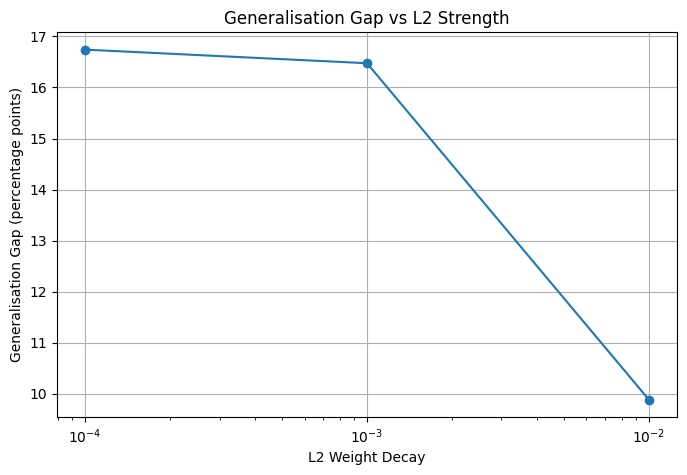

In [94]:
# ============================================================
# L2 GAP PLOT
# ============================================================

l2_gaps = [
    result[4]
    for result in l2_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    l2_values,
    l2_gaps,
    marker="o"
)

plt.xscale("log")

plt.xlabel("L2 Weight Decay")

plt.ylabel("Generalisation Gap (percentage points)")

plt.title("Generalisation Gap vs L2 Strength")

plt.grid(True)

plt.show()

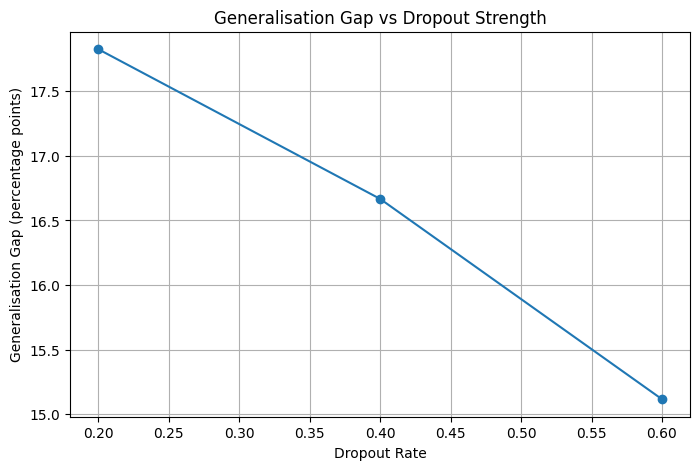

In [95]:
# ============================================================
# DROPOUT GAP PLOT
# ============================================================

dropout_gaps = [
    result[4]
    for result in dropout_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_rates,
    dropout_gaps,
    marker="o"
)

plt.xlabel("Dropout Rate")

plt.ylabel("Generalisation Gap (percentage points)")

plt.title("Generalisation Gap vs Dropout Strength")

plt.grid(True)

plt.show()

In [ ]:
#Among the tested methods, L2 weight decay with λ = 0.001 gave the 
#largest gap reduction while keeping the loss in training accuracy relatively small
#among the L2 settings. The baseline gap was 17.07%, which decreased to 16.48%, while
#training accuracy decreased from 99.30% to 98.40%. This represents a 0.59 percentage-point
#reduction in the gap with only a 0.90 percentage-point loss in training accuracy. Although L2 with λ = 0.01
#reduced the gap much more, its training accuracy dropped considerably to 89.80%. Therefore, L2 with λ

In [98]:
# PART 7 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import random

In [99]:
class TunedMLP(nn.Module):

    def __init__(self, hidden_size=64, dropout_rate=0.0):

        super().__init__()

        self.fc1 = nn.Linear(
            X_train.shape[1],
            hidden_size
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            dropout_rate
        )

        self.fc2 = nn.Linear(
            hidden_size,
            10
        )

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [101]:
search_space = {
    "learning_rate": [
        0.0001,
        0.001,
        0.01
    ],

    "hidden_size": [
        32,
        64,
        128
    ],

    "dropout_rate": [
        0.0,
        0.2,
        0.4
    ]
}

In [103]:
best_l2_value = 0.001

In [111]:
def train_fold(
    X_tr,
    y_tr,
    X_va,
    y_va,
    config,
    epochs=50
):

    model = TunedMLP(
        hidden_size=config["hidden_size"],
        dropout_rate=config["dropout_rate"]
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=best_l2_value
    )

    X_tr = torch.tensor(
        X_tr,
        dtype=torch.float32
    )

    y_tr = torch.tensor(
        y_tr,
        dtype=torch.long
    )

    X_va = torch.tensor(
        X_va,
        dtype=torch.float32
    )

    y_va = torch.tensor(
        y_va,
        dtype=torch.long
    )

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        output = model(X_tr)

        loss = criterion(
            output,
            y_tr
        )

        loss.backward()

        optimizer.step()

    model.eval()

    with torch.no_grad():

        validation_output = model(X_va)

        predictions = torch.argmax(
            validation_output,
            dim=1
        )

    accuracy = (
        predictions == y_va
    ).float().mean().item()

    return accuracy

In [113]:
all_configs = []

for lr in search_space["learning_rate"]:

    for hidden in search_space["hidden_size"]:

        for dropout in search_space["dropout_rate"]:

            all_configs.append({
                "learning_rate": lr,
                "hidden_size": hidden,
                "dropout_rate": dropout
            })


random.seed(42)

random.shuffle(all_configs)

selected_configs = all_configs[:12]

print("12 Random Configurations:")

for i, config in enumerate(
    selected_configs,
    1
):

    print(
        i,
        config
    )

12 Random Configurations:
1 {'learning_rate': 0.001, 'hidden_size': 128, 'dropout_rate': 0.2}
2 {'learning_rate': 0.001, 'hidden_size': 64, 'dropout_rate': 0.0}
3 {'learning_rate': 0.001, 'hidden_size': 32, 'dropout_rate': 0.0}
4 {'learning_rate': 0.01, 'hidden_size': 128, 'dropout_rate': 0.4}
5 {'learning_rate': 0.01, 'hidden_size': 32, 'dropout_rate': 0.2}
6 {'learning_rate': 0.0001, 'hidden_size': 128, 'dropout_rate': 0.0}
7 {'learning_rate': 0.0001, 'hidden_size': 64, 'dropout_rate': 0.4}
8 {'learning_rate': 0.001, 'hidden_size': 32, 'dropout_rate': 0.2}
9 {'learning_rate': 0.001, 'hidden_size': 128, 'dropout_rate': 0.0}
10 {'learning_rate': 0.01, 'hidden_size': 64, 'dropout_rate': 0.2}
11 {'learning_rate': 0.001, 'hidden_size': 32, 'dropout_rate': 0.4}
12 {'learning_rate': 0.01, 'hidden_size': 32, 'dropout_rate': 0.0}


In [114]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for i, config in enumerate(
    selected_configs,
    1
):

    fold_scores = []

    for train_index, val_index in skf.split(
        X_train,
        y_train
    ):

        X_tr = X_train[train_index]
        X_va = X_train[val_index]

        y_tr = y_train[train_index]
        y_va = y_train[val_index]

        score = train_fold(
            X_tr,
            y_tr,
            X_va,
            y_va,
            config,
            epochs=50
        )

        fold_scores.append(score)

    mean_score = np.mean(
        fold_scores
    )

    std_score = np.std(
        fold_scores
    )

    cv_results.append({
        "config": config,
        "mean_cv_accuracy": mean_score,
        "std_cv_accuracy": std_score
    })

    print(
        f"Config {i}/12 | "
        f"Mean: {mean_score:.4f} | "
        f"Std: {std_score:.4f}"
    )

Config 1/12 | Mean: 0.7922 | Std: 0.0060
Config 2/12 | Mean: 0.7669 | Std: 0.0059
Config 3/12 | Mean: 0.7282 | Std: 0.0129
Config 4/12 | Mean: 0.8439 | Std: 0.0041
Config 5/12 | Mean: 0.8139 | Std: 0.0084
Config 6/12 | Mean: 0.6251 | Std: 0.0335
Config 7/12 | Mean: 0.5396 | Std: 0.0286
Config 8/12 | Mean: 0.7145 | Std: 0.0157
Config 9/12 | Mean: 0.8000 | Std: 0.0045
Config 10/12 | Mean: 0.8367 | Std: 0.0042
Config 11/12 | Mean: 0.7091 | Std: 0.0119
Config 12/12 | Mean: 0.8313 | Std: 0.0032


In [115]:
cv_results = sorted(
    cv_results,
    key=lambda x: x["mean_cv_accuracy"],
    reverse=True
)

print("\n===== TOP 5 CONFIGURATIONS =====")

for i, result in enumerate(
    cv_results[:5],
    1
):

    print(f"\nRank {i}")

    print(
        "Configuration:",
        result["config"]
    )

    print(
        f"Mean CV Accuracy: "
        f"{result['mean_cv_accuracy']:.4f}"
    )

    print(
        f"Standard Deviation: "
        f"{result['std_cv_accuracy']:.4f}"
    )


===== TOP 5 CONFIGURATIONS =====

Rank 1
Configuration: {'learning_rate': 0.01, 'hidden_size': 128, 'dropout_rate': 0.4}
Mean CV Accuracy: 0.8439
Standard Deviation: 0.0041

Rank 2
Configuration: {'learning_rate': 0.01, 'hidden_size': 64, 'dropout_rate': 0.2}
Mean CV Accuracy: 0.8367
Standard Deviation: 0.0042

Rank 3
Configuration: {'learning_rate': 0.01, 'hidden_size': 32, 'dropout_rate': 0.0}
Mean CV Accuracy: 0.8313
Standard Deviation: 0.0032

Rank 4
Configuration: {'learning_rate': 0.01, 'hidden_size': 32, 'dropout_rate': 0.2}
Mean CV Accuracy: 0.8139
Standard Deviation: 0.0084

Rank 5
Configuration: {'learning_rate': 0.001, 'hidden_size': 128, 'dropout_rate': 0.0}
Mean CV Accuracy: 0.8000
Standard Deviation: 0.0045


In [116]:
best_config = cv_results[0]["config"]

print("\n===== SELECTED CONFIGURATION =====")

print(
    "Learning rate:",
    best_config["learning_rate"]
)

print(
    "Hidden size:",
    best_config["hidden_size"]
)

print(
    "Dropout rate:",
    best_config["dropout_rate"]
)

print(
    "L2 weight decay:",
    best_l2_value
)

print(
    f"Mean CV Accuracy: "
    f"{cv_results[0]['mean_cv_accuracy']:.4f}"
)

print(
    f"Std CV Accuracy: "
    f"{cv_results[0]['std_cv_accuracy']:.4f}"
)


===== SELECTED CONFIGURATION =====
Learning rate: 0.01
Hidden size: 128
Dropout rate: 0.4
L2 weight decay: 0.001
Mean CV Accuracy: 0.8439
Std CV Accuracy: 0.0041


In [117]:
final_model = TunedMLP(
    hidden_size=best_config["hidden_size"],
    dropout_rate=best_config["dropout_rate"]
)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_config["learning_rate"],
    weight_decay=best_l2_value
)

X_full = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_full = torch.tensor(
    y_train,
    dtype=torch.long
)

for epoch in range(200):

    final_model.train()

    optimizer.zero_grad()

    output = final_model(X_full)

    loss = criterion(
        output,
        y_full
    )

    loss.backward()

    optimizer.step()

print("Final model training completed.")

Final model training completed.


In [118]:
final_model.eval()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

with torch.no_grad():

    test_output = final_model(
        X_test_tensor
    )

    test_predictions = torch.argmax(
        test_output,
        dim=1
    ).numpy()

In [120]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

cm = confusion_matrix(
    y_test,
    test_predictions
)

print("\n===== FINAL TEST RESULTS =====")

print(
    f"Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: "
    f"{test_precision:.4f}"
)

print(
    f"Macro Recall: "
    f"{test_recall:.4f}"
)

print(
    f"Macro F1: "
    f"{test_f1:.4f}"
)

print("\nConfusion Matrix:")

print(cm)


===== FINAL TEST RESULTS =====
Accuracy: 87.23%
Macro Precision: 0.8711
Macro Recall: 0.8723
Macro F1: 0.8709

Confusion Matrix:
[[850   3  15  33   1   3  83   0  12   0]
 [  1 971   3  18   1   1   5   0   0   0]
 [ 13   1 810  11 107   0  50   0   8   0]
 [ 30  15  17 903  22   0  11   0   2   0]
 [  0   0  80  31 824   0  62   0   3   0]
 [  2   0   0   1   0 926   0  45   5  21]
 [177   6 104  20  77   0 603   0  12   1]
 [  0   0   0   0   0  33   0 927   0  40]
 [  2   0  10   3   4   4   7   5 963   2]
 [  0   0   0   0   0   9   0  44   1 946]]


In [123]:
part2_baseline_accuracy = 60.40   # CHANGE THIS

improvement = (
    test_accuracy * 100
    - part2_baseline_accuracy
)

print(
    f"Improvement over Part 2 baseline: "
    f"{improvement:.2f} percentage points"
)

Improvement over Part 2 baseline: 26.83 percentage points


In [ ]:
#The Part 2 baseline accuracy was 60.40%, while the tuned model achieved a test accuracy of 87.23%. Therefore, the tuned model improved the accuracy by 26.83 percentage points over the Part 2 baseline.